In [1]:
import numpy as np
import matplotlib.pyplot as plt 

# Time Series from Point Tracking

In [2]:
data = np.load("../data/220516_No contraction videos.npy")

In [3]:
data.shape

(10, 1208)

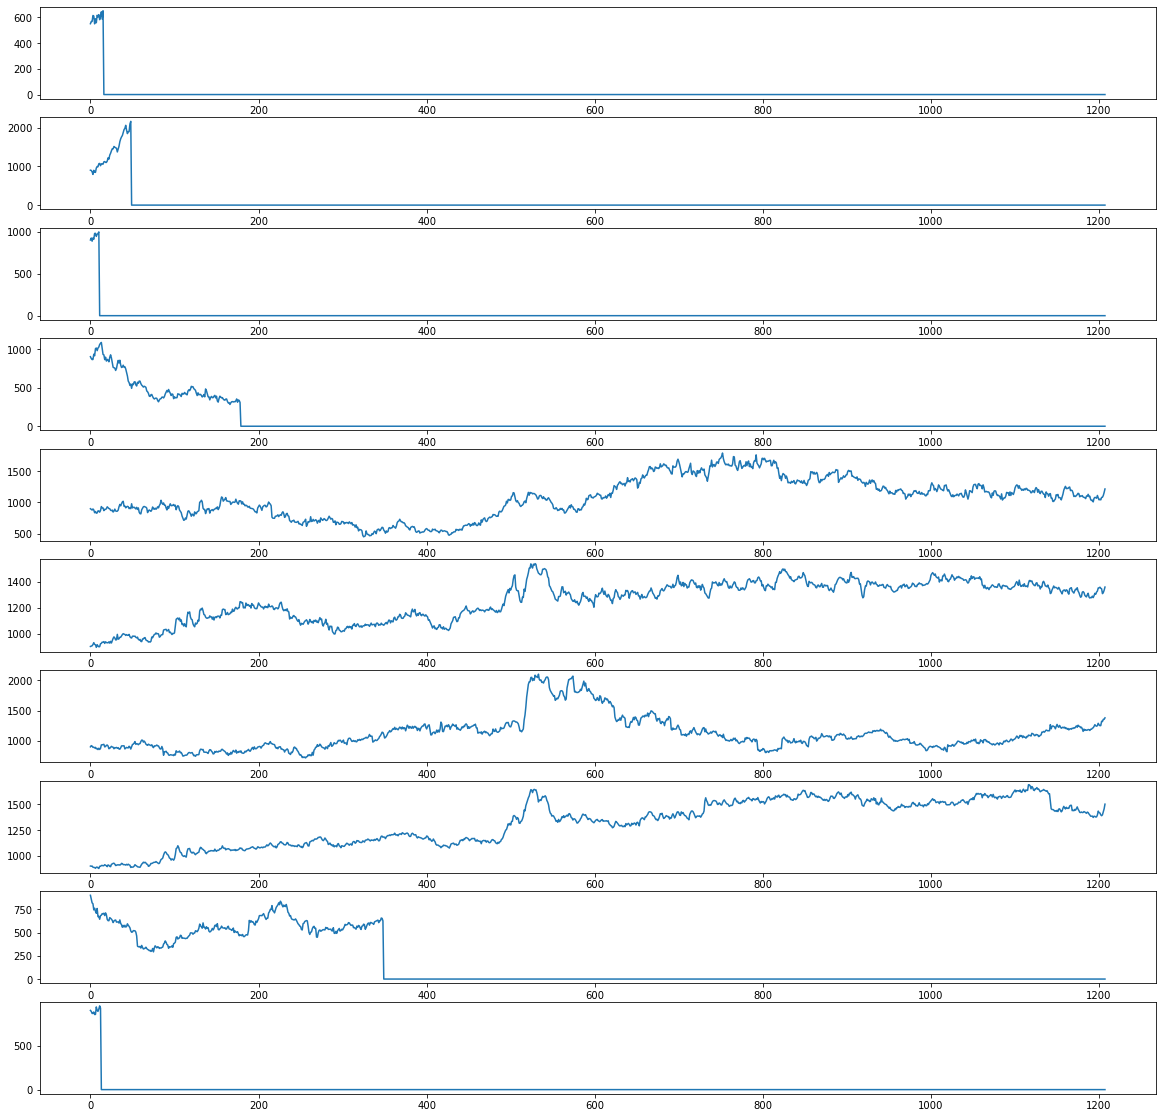

In [4]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(data[i,:]);

* time series contain noise
* time series contain (non-linear)-trend

# FFT on raw time series

In [5]:
y = np.zeros(data.shape)
for i in range(data.shape[0]):
    y[i,:] = np.fft.fft(data[i,:])

<ipython-input-5-65fd3f12b7db>:3: ComplexWarning: Casting complex values to real discards the imaginary part
  y[i,:] = np.fft.fft(data[i,:])


In [6]:
y.shape[1]

1208

605


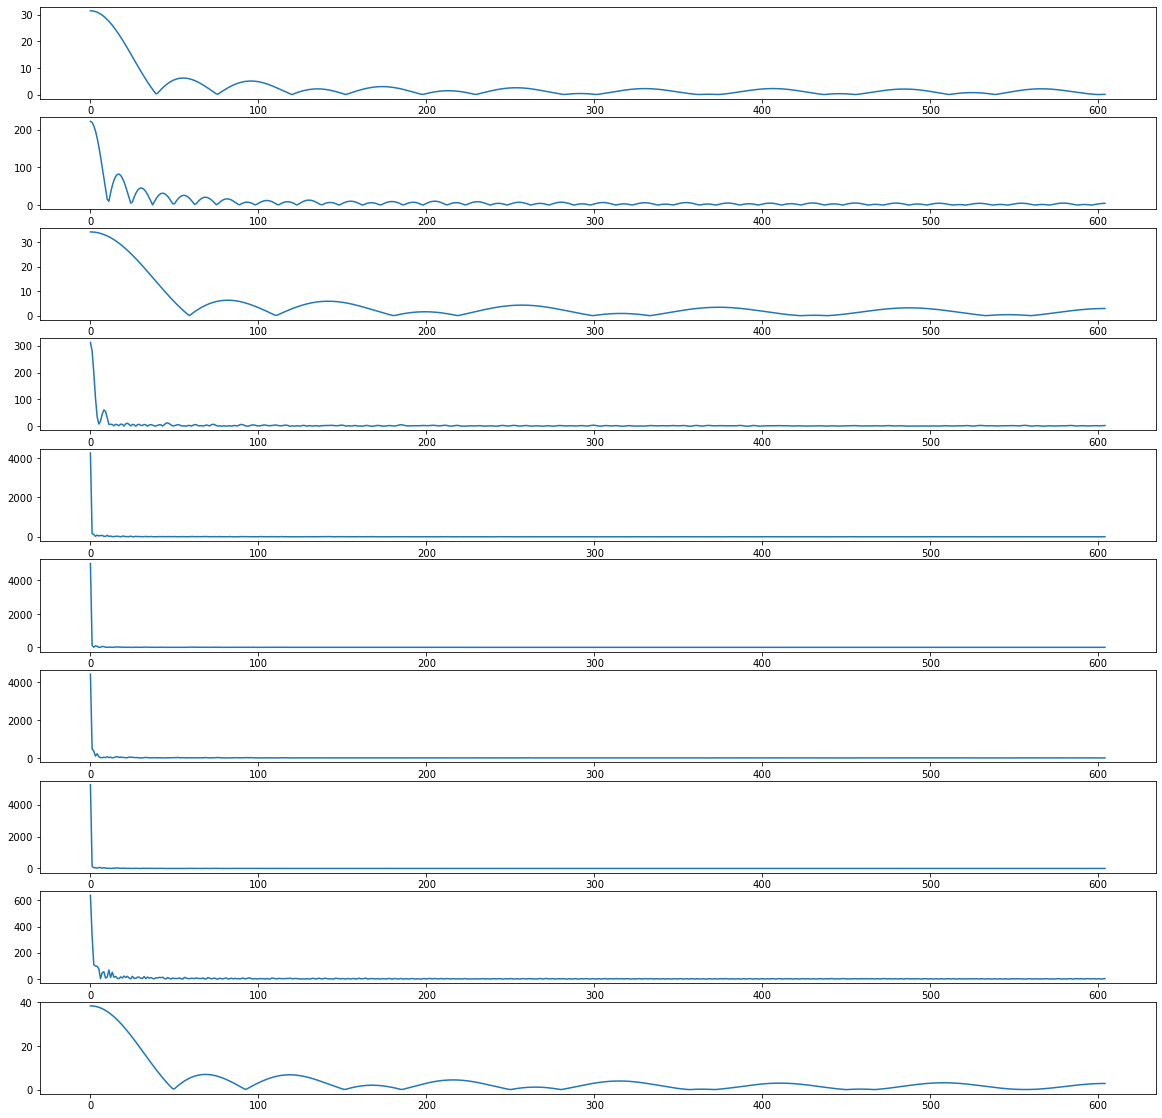

In [7]:
N = int(y.shape[1]/2) + 1
print(N)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(2*abs(y[i,:N])/N);

## Window Functions

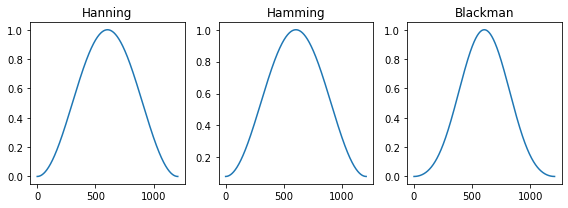

In [8]:
hann = np.hanning(data.shape[1])
hamm = np.hamming(data.shape[1])
black= np.blackman(data.shape[1])

plt.figure(figsize=(8,3))
plt.subplot(131)
plt.plot(hann)
plt.title('Hanning')
plt.subplot(132)
plt.plot(hamm)
plt.title('Hamming')
plt.subplot(133)
plt.plot(black)
plt.title('Blackman')
plt.tight_layout()

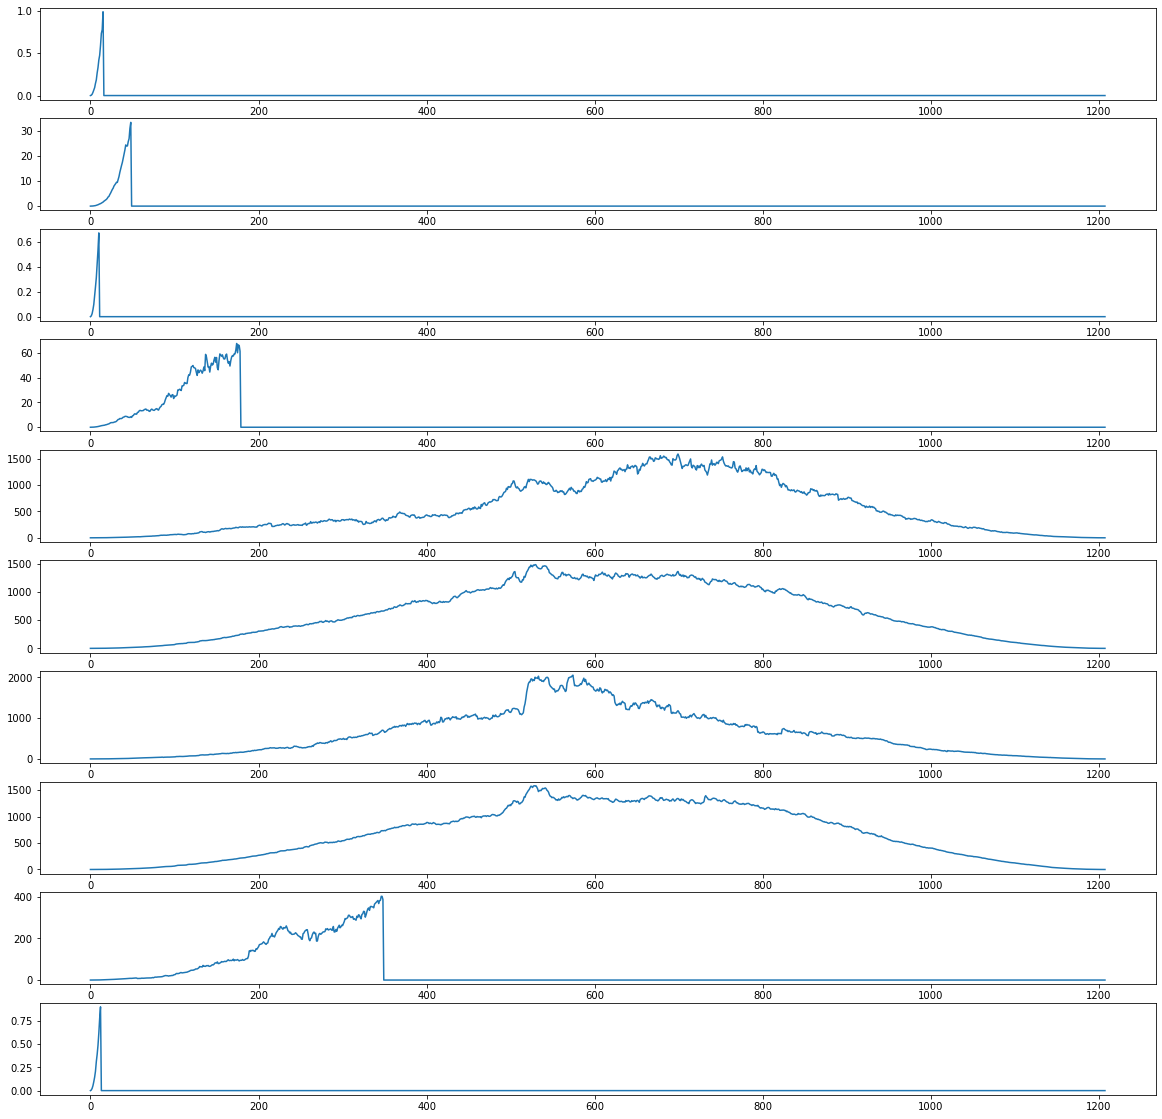

In [9]:
signal_hann = np.zeros(data.shape)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    signal_hann[i,:] = data[i,:]*hann
    ax.plot(signal_hann[i,:]);

In [10]:
y_hann = np.zeros(data.shape)
for i in range(data.shape[0]):
    y_hann[i,:] = np.fft.fft(signal_hann[i,:])

<ipython-input-10-91ed8f5c1b67>:3: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])


605


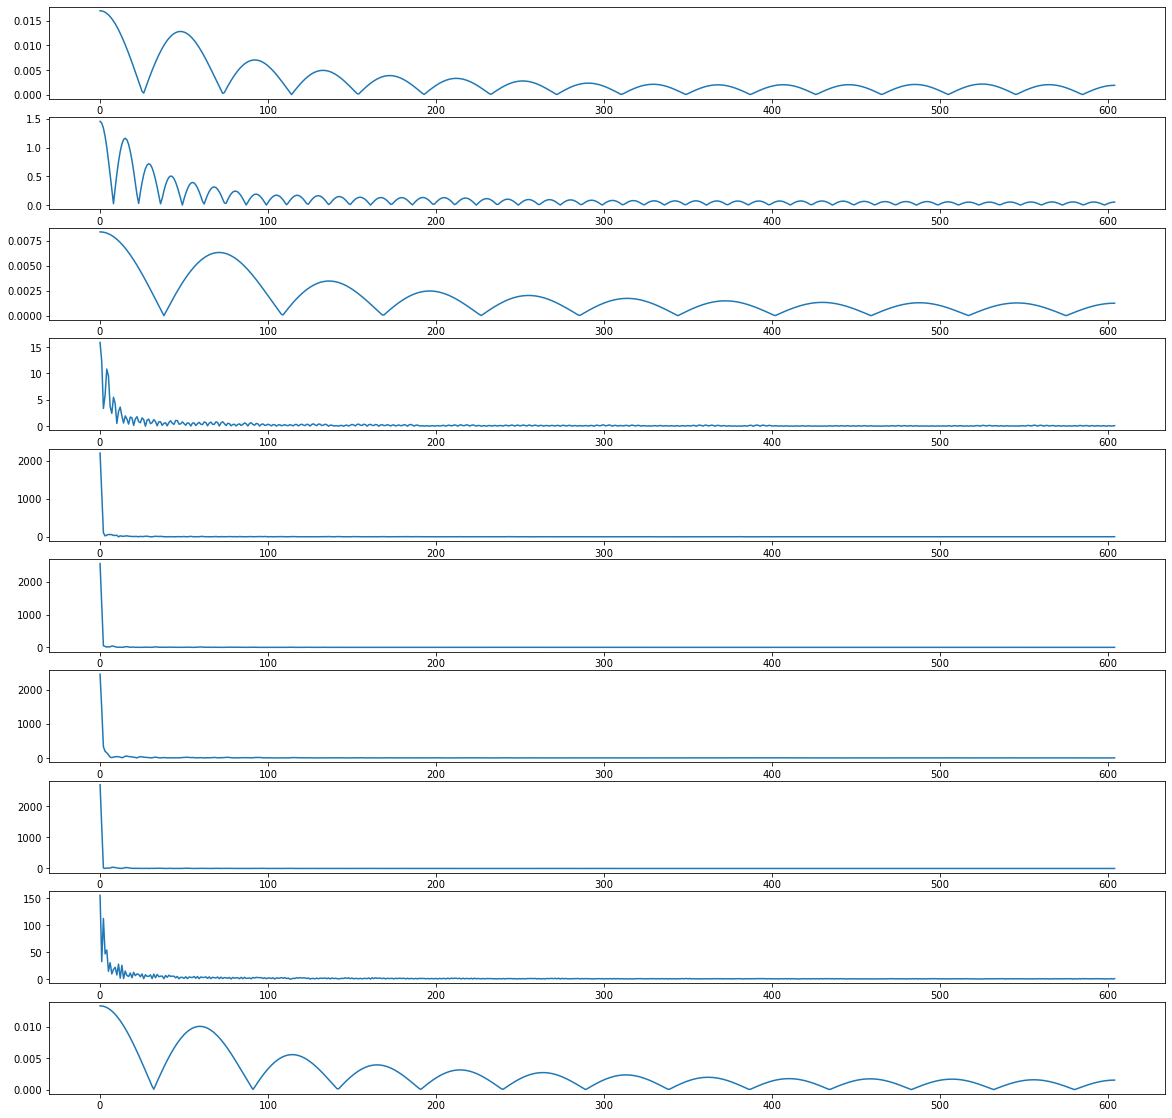

In [11]:
N = int(y.shape[1]/2) + 1
print(N)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(2*abs(y_hann[i,:N])/N);

# Plot Period instead of Frequency

In [12]:
fa = 1.0 # every 1 timestep
print('fa=%.4fHz (Frequency)' % fa)

fa=1.0000Hz (Frequency)


In [13]:
X = np.linspace(0, fa/2, N, endpoint=True)

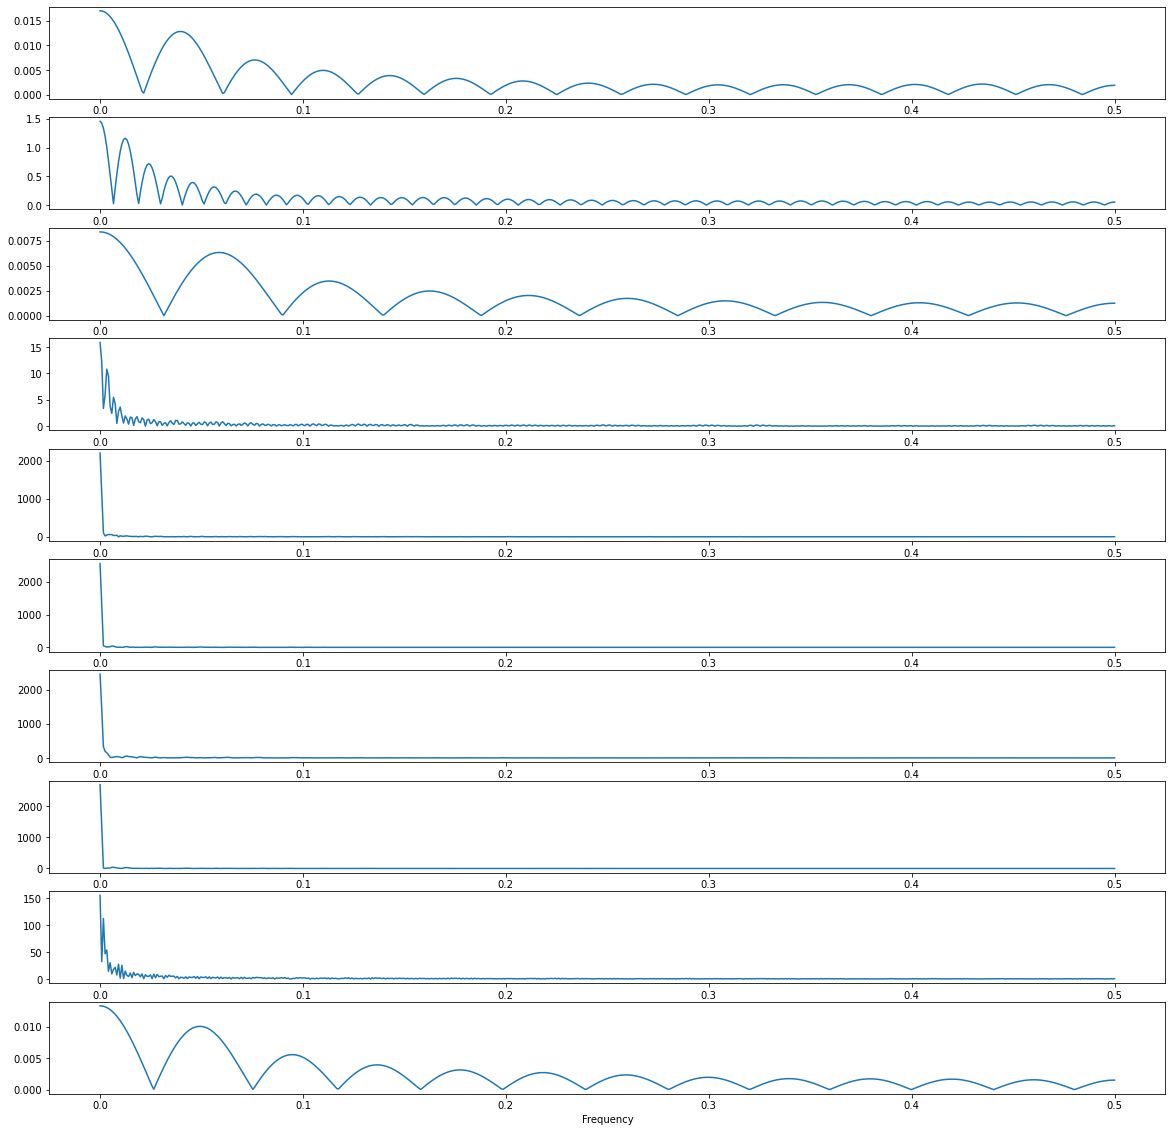

In [14]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(X, 2.0*np.abs(y_hann[i,:N])/N)
    ax.set_xlabel('Frequency')

In [15]:
Xp = 1.0/X # in timestep units

<ipython-input-15-1f6d2b9e9da6>:1: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X # in timestep units


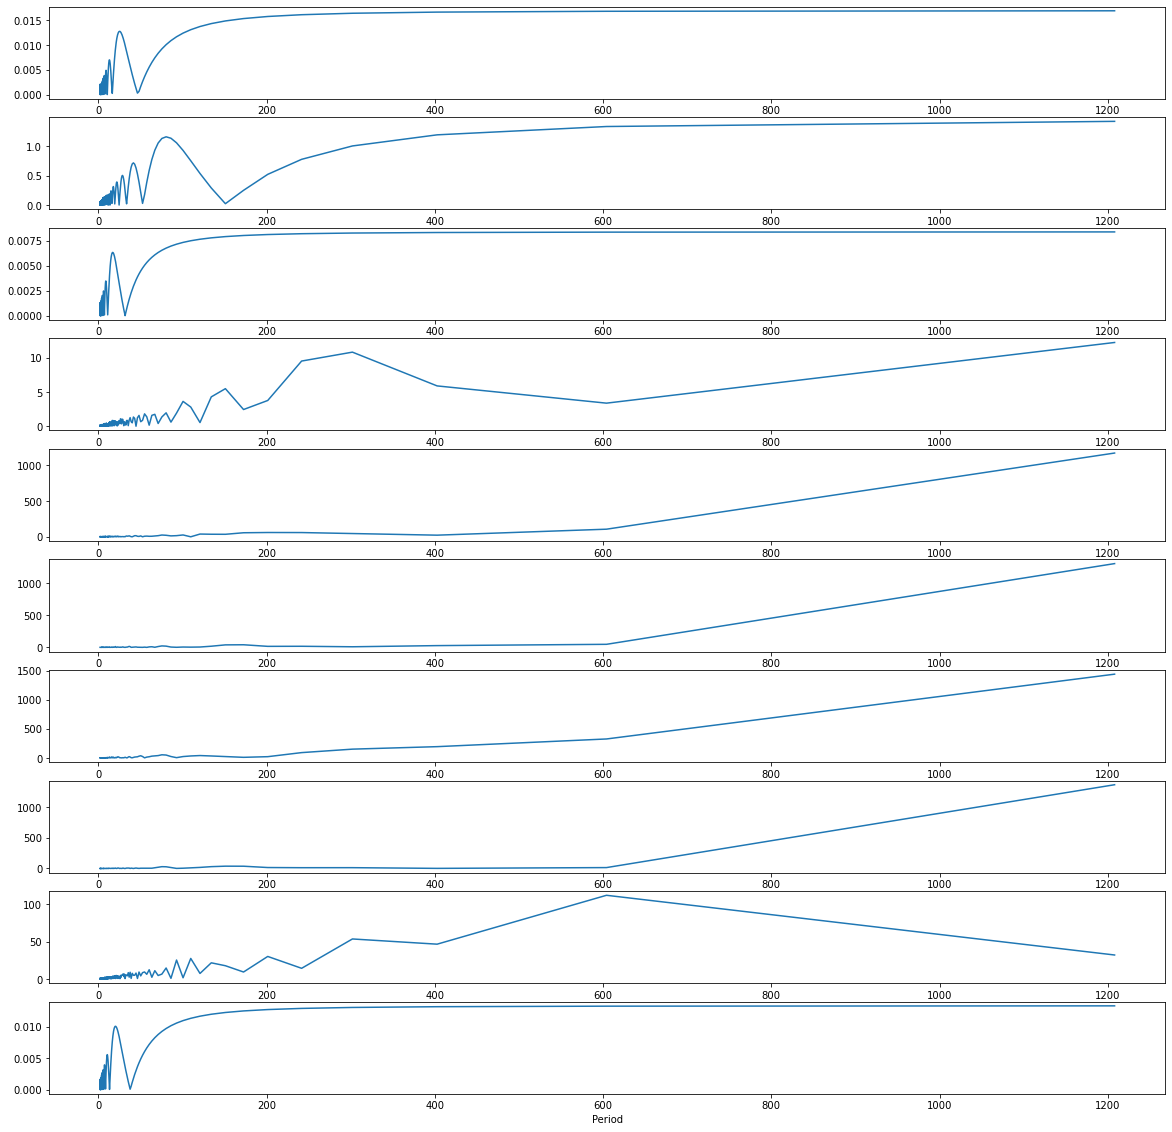

In [16]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(Xp, 2.0*np.abs(y_hann[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')

# Apply running mean to time series before FFT

In [17]:
n=5
len(np.convolve(data[0,:], np.ones(n)/n, mode='valid'))

1204

In [18]:
n=5
data_smooth = np.zeros((data.shape[0], data.shape[1]-(n-1)))
for i in range(data.shape[0]):
    data_smooth[i,:] = np.convolve(data[i,:], np.ones(n)/n, mode='valid')

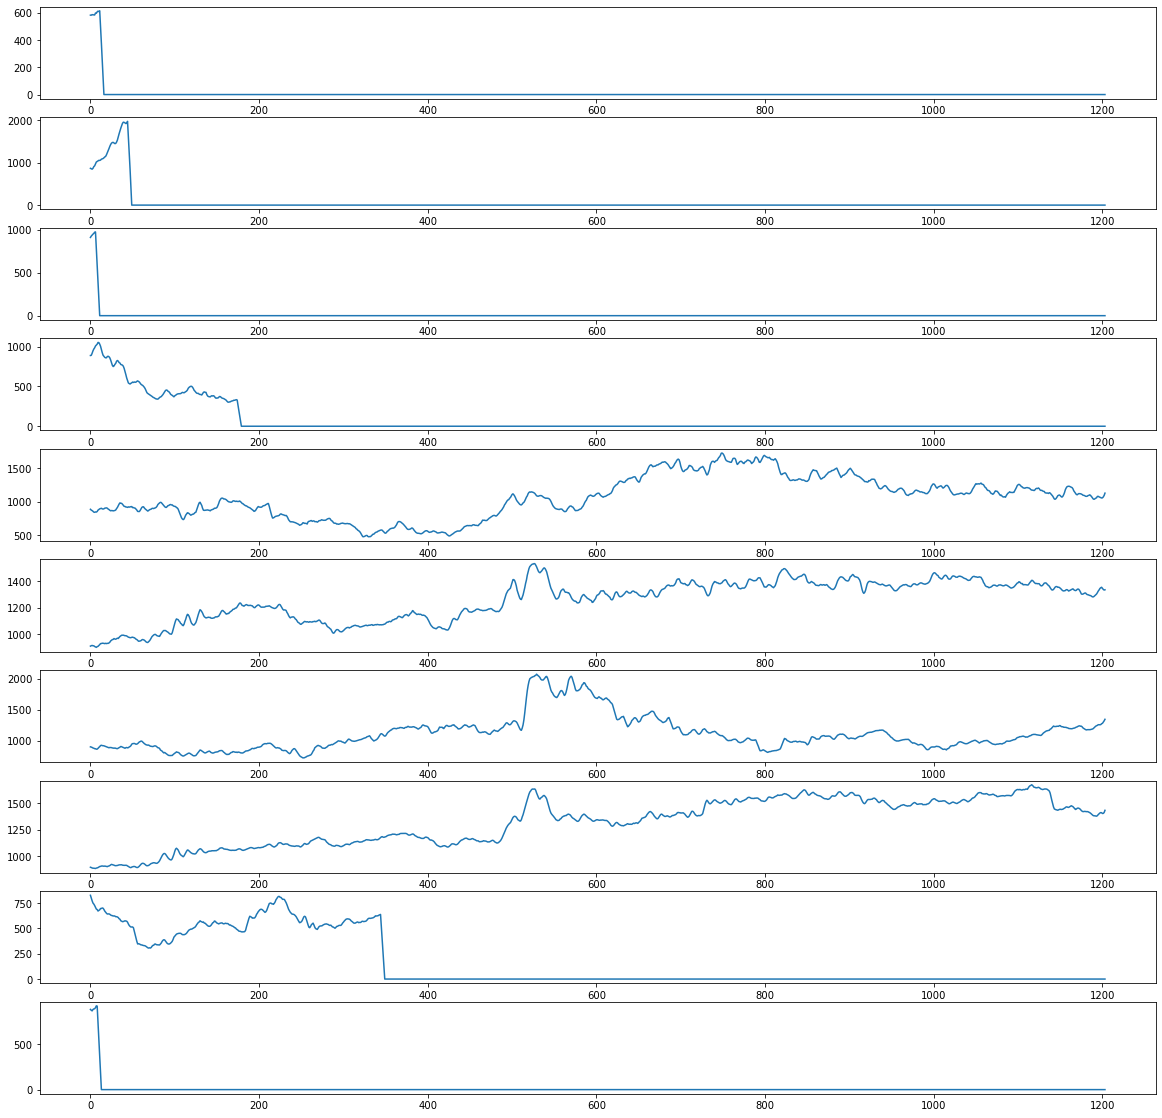

In [19]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(data_smooth[i,:]);

In [20]:
hann_s = np.hanning(data.shape[1]-(n-1))
hamm_s = np.hamming(data.shape[1]-(n-1))
black_s= np.blackman(data.shape[1]-(n-1))

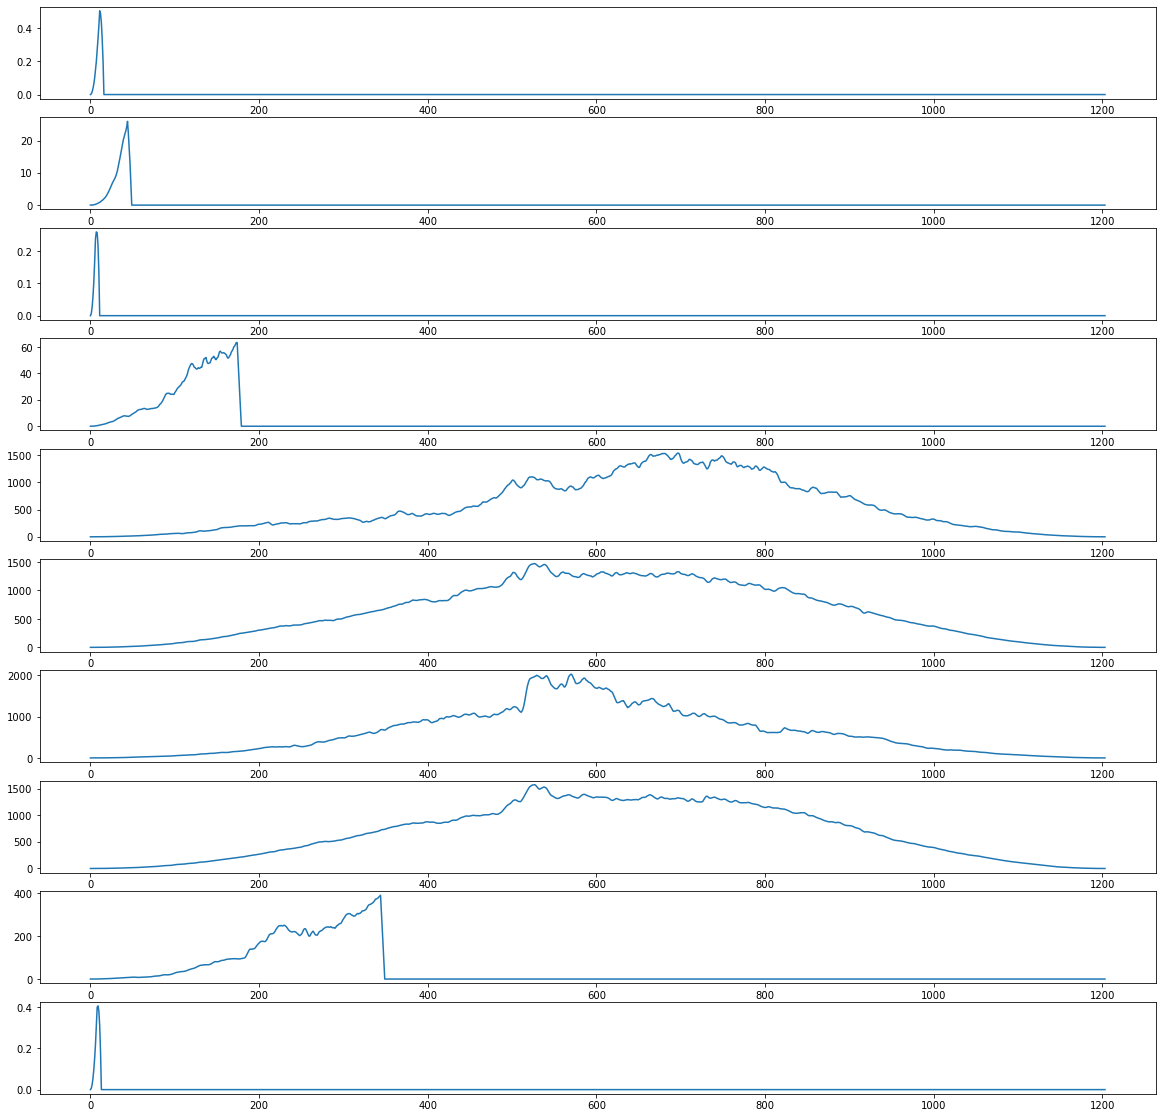

In [21]:
signal_hann_s = np.zeros((data.shape[0], data.shape[1]-(n-1)))
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    signal_hann_s[i,:] = data_smooth[i,:]*hann_s
    ax.plot(signal_hann_s[i,:]);

In [22]:
y_hann_s = np.zeros(data_smooth.shape)
for i in range(data_smooth.shape[0]):
    y_hann_s[i,:] = np.fft.fft(signal_hann_s[i,:])

<ipython-input-22-763799cfe925>:3: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann_s[i,:] = np.fft.fft(signal_hann_s[i,:])


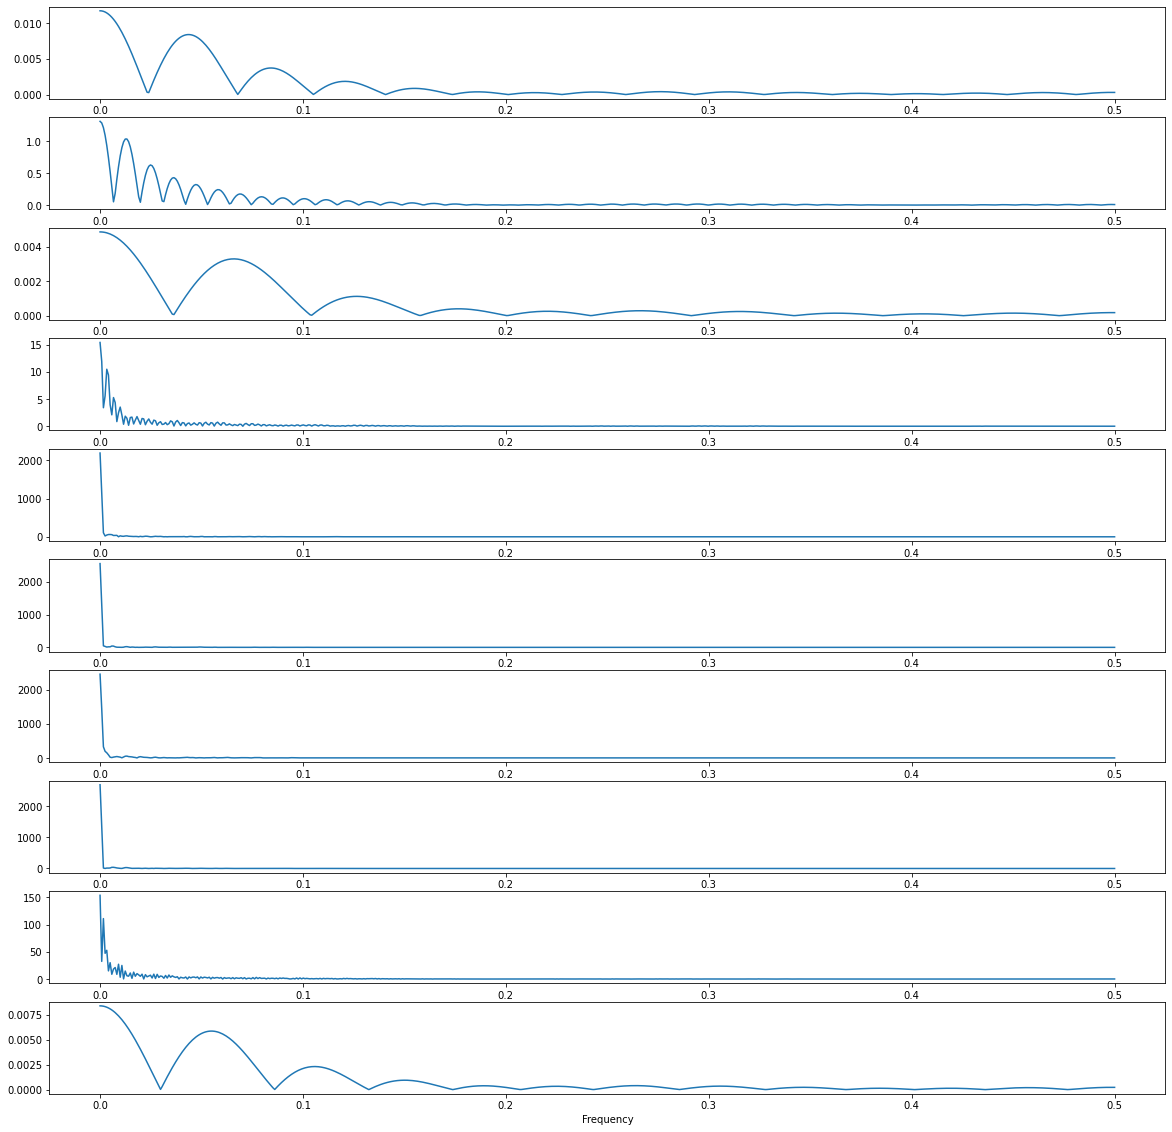

In [23]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(X, 2.0*np.abs(y_hann_s[i,:N])/N)
    ax.set_xlabel('Frequency')

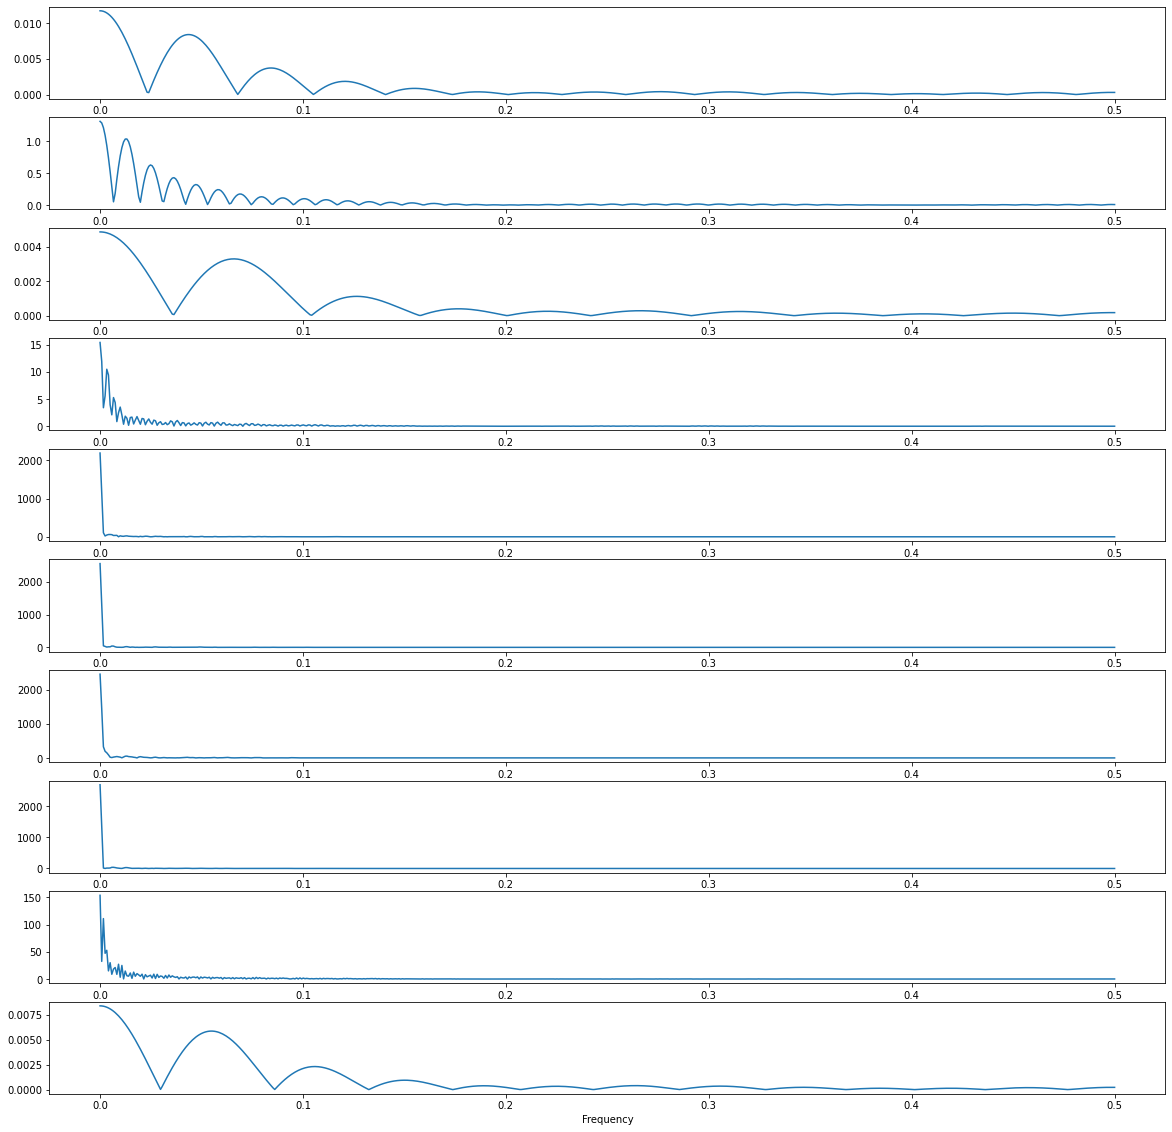

In [24]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(X, 2.0*np.abs(y_hann_s[i,:N])/N)
    ax.set_xlabel('Frequency')

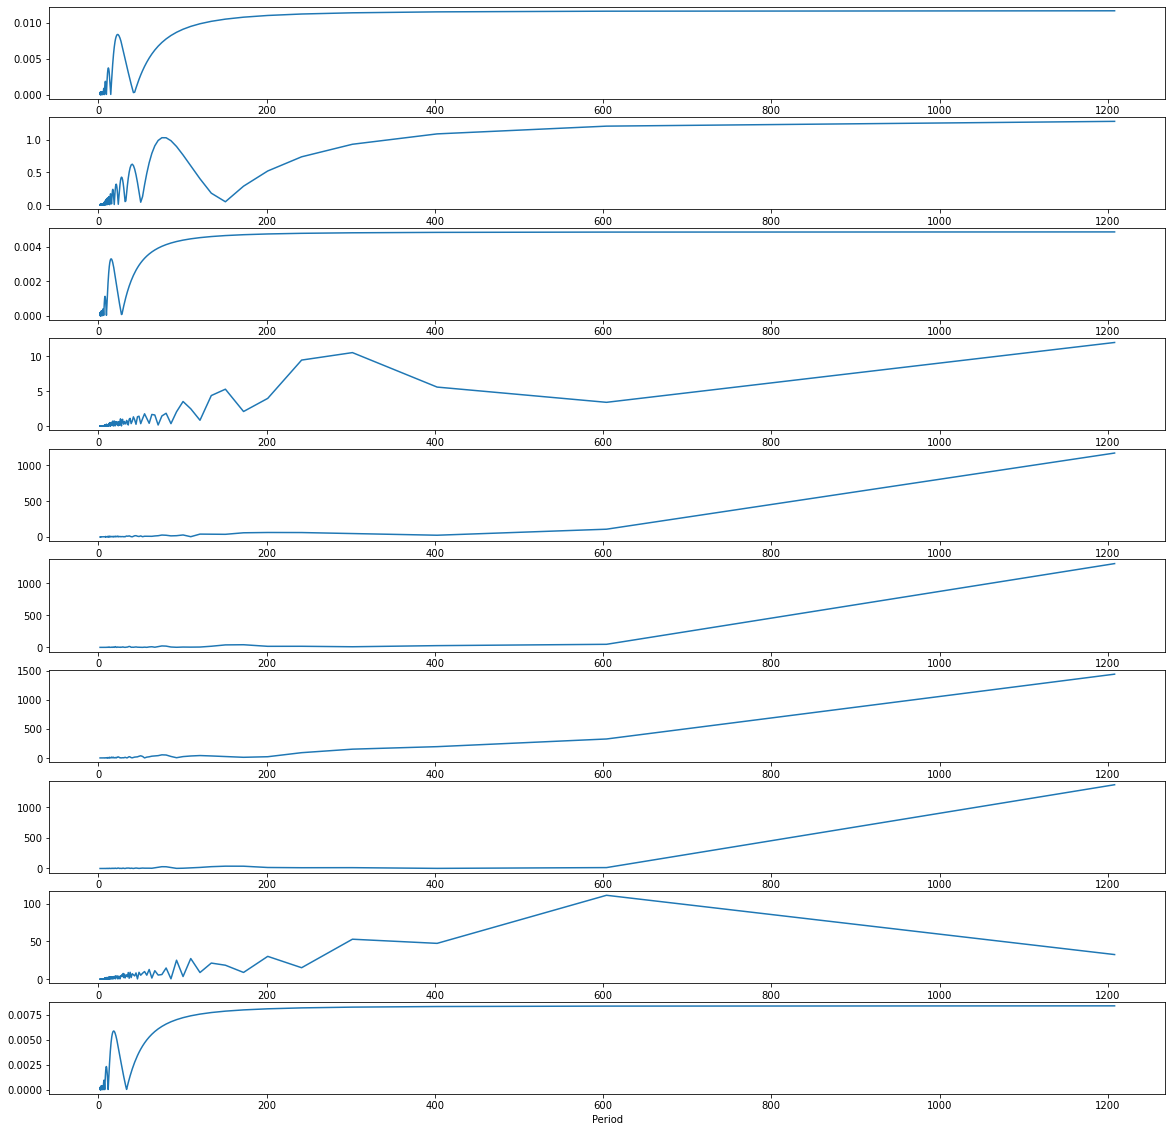

In [25]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis.flatten()):
    ax.plot(Xp, 2.0*np.abs(y_hann_s[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')

# Detrending

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
x = np.linspace(0, data[0,:].shape[0], data[0,:].shape[0])
predicted = np.zeros(data.shape)

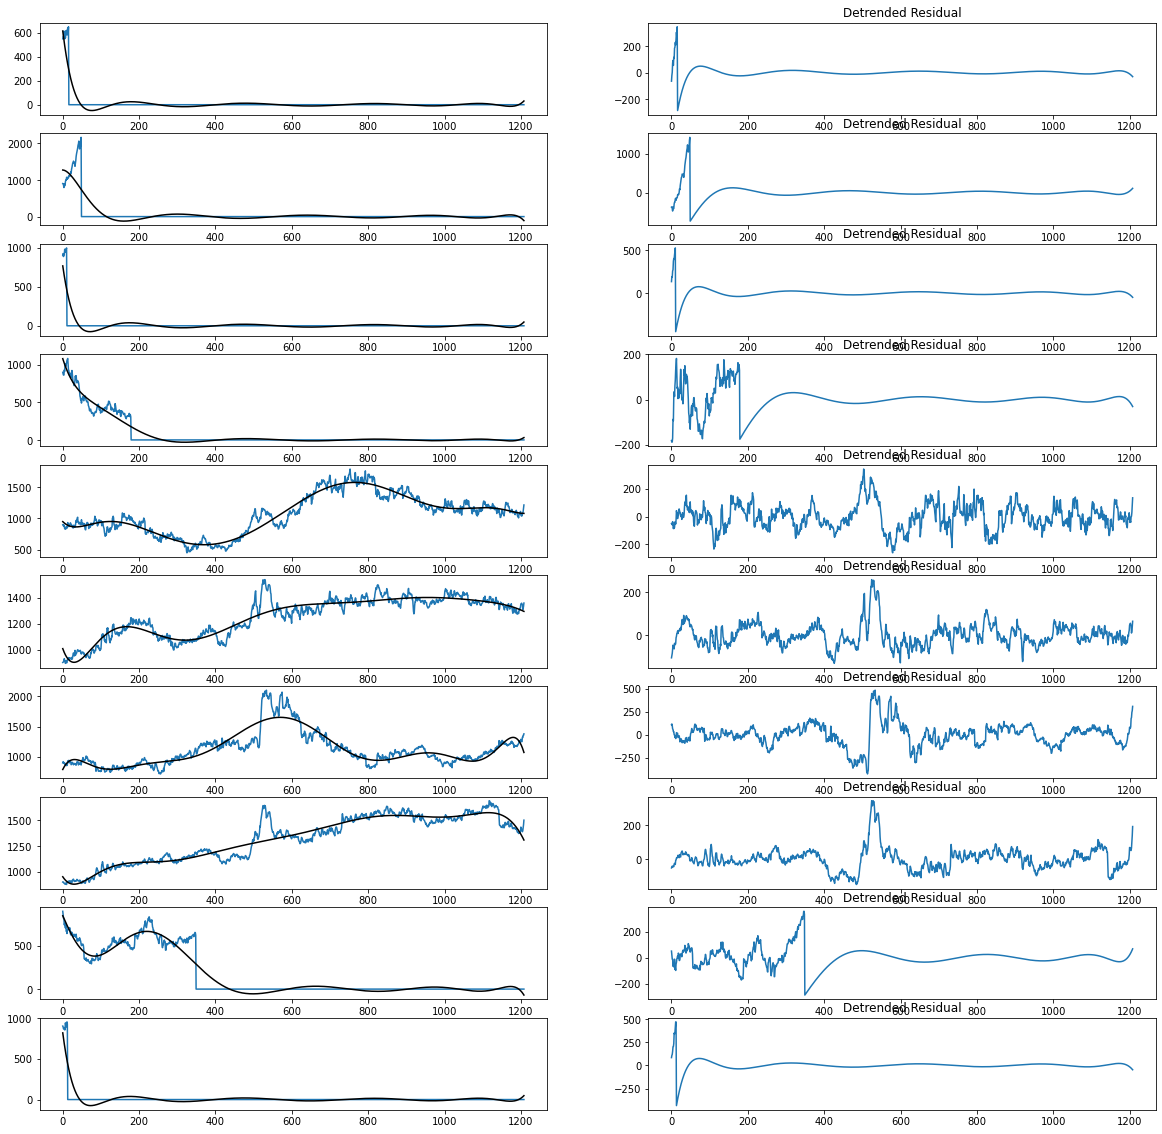

In [28]:
# Detrend with a 2d order polynomial
for i in range(data.shape[0]):
    y = data[i,:]
    model = np.polyfit(x, y, 10)
    predicted[i,:] = np.polyval(model, x)
    #lr = LinearRegression()
    #model = lr.fit(x.reshape(-1, 1),y.reshape(-1, 1))
    #pred = lr.predict(x.reshape(-1, 1))#np.polyval(model, x)
    #predicted[i,:] = np.squeeze(pred)
    
fig, axis = plt.subplots(10, 2, figsize=(20,20))
for i, ax in enumerate(axis):
    axis[i,0].plot(x, data[i,:])
    axis[i,0].plot(x, predicted[i,:], 'k-')
    
    axis[i,1].plot(x, data[i,:] - predicted[i,:])
    axis[i,1].set(title='Detrended Residual')

In [29]:
data_de = data - predicted

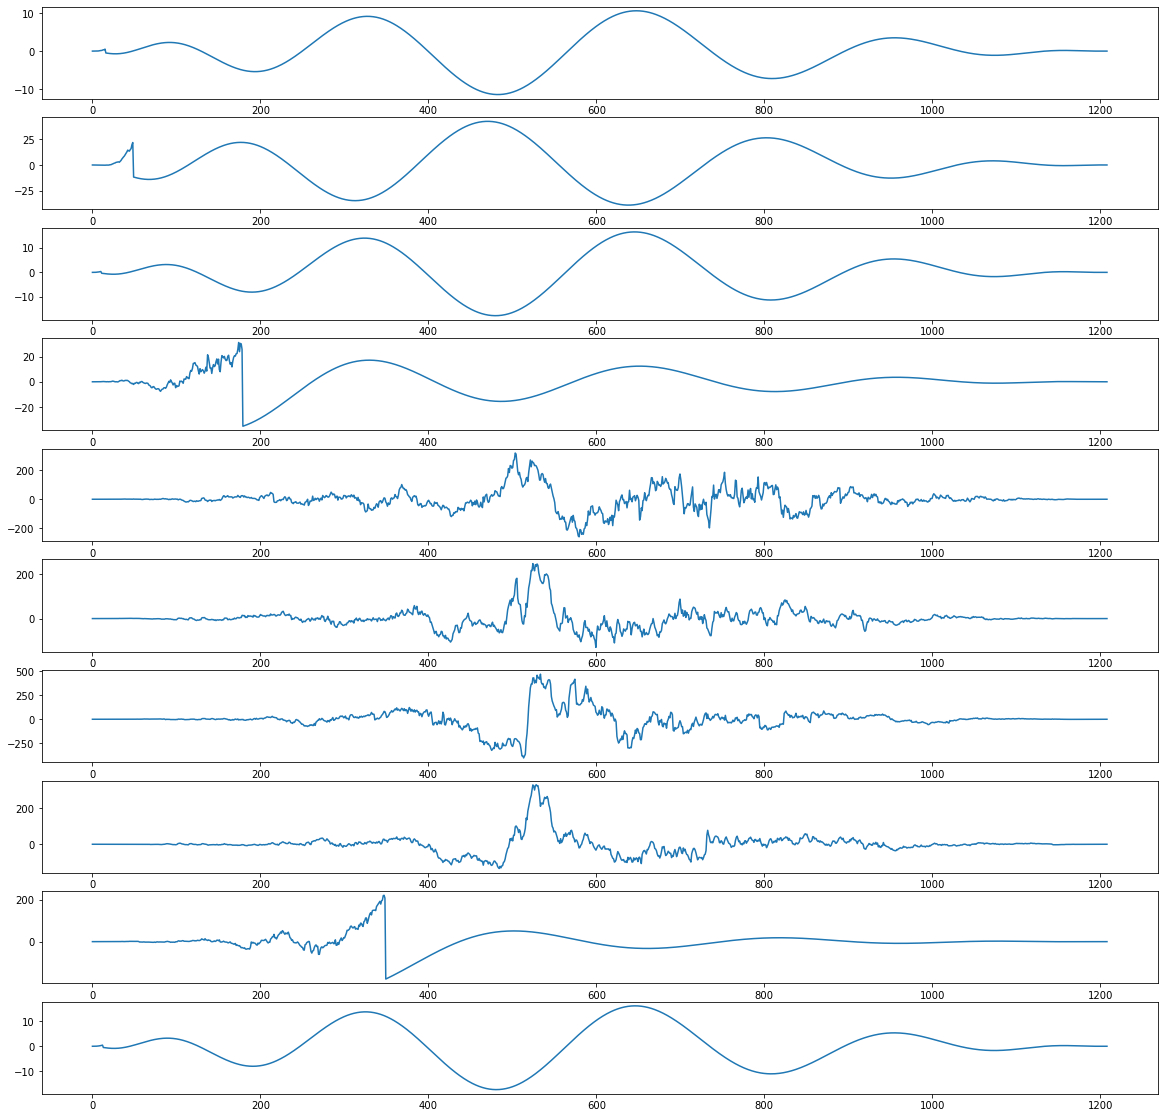

In [30]:
signal_hann = np.zeros(data_de.shape)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    signal_hann[i,:] = data_de[i,:]*hann
    ax.plot(x, signal_hann[i,:]);

<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-31-e62683810e18>:4: ComplexWarning: Casting complex val

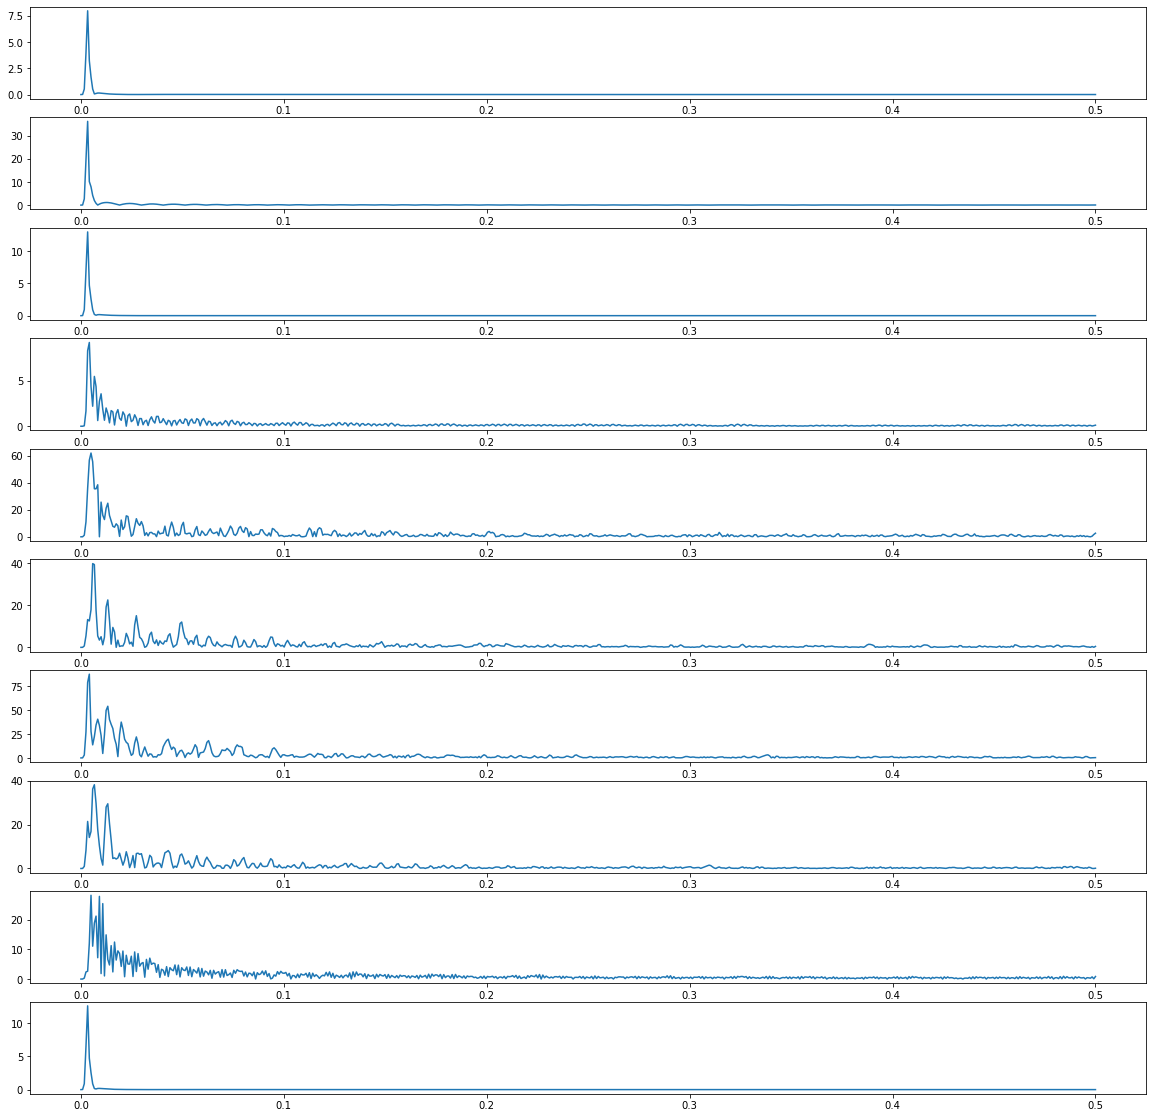

In [31]:
y_hann = np.zeros(signal_hann.shape)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    y_hann[i,:] = np.fft.fft(signal_hann[i,:])
    ax.plot(X, 2.0*np.abs(y_hann[i,:N])/N);

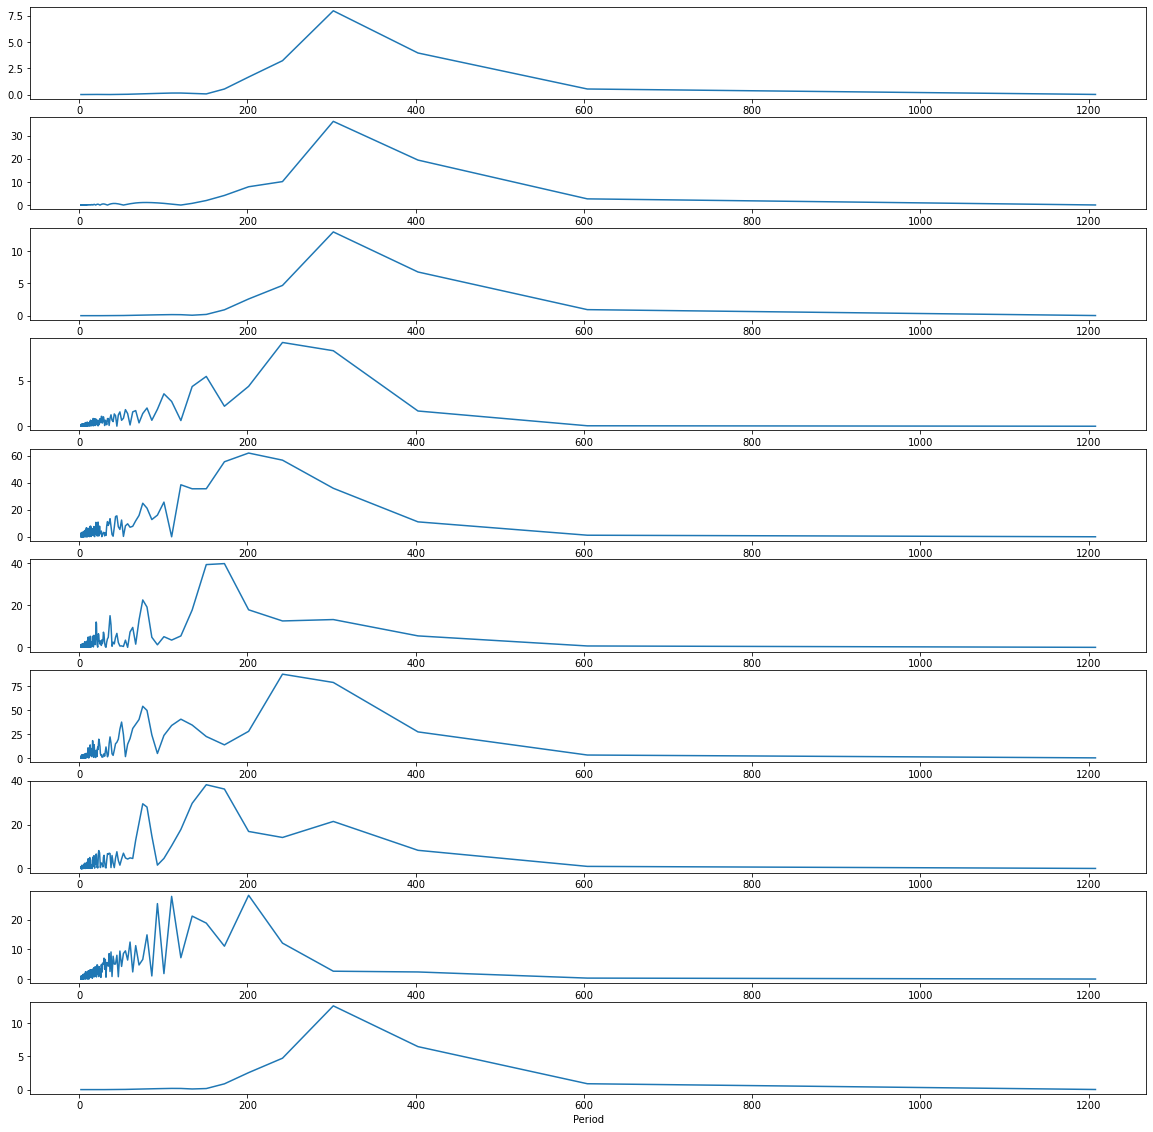

In [32]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    ax.plot(Xp, 2.0*np.abs(y_hann[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')

# normalize time series

In [33]:
mean = np.mean(data,axis=1).reshape(-1,1)
std = np.std(data,axis=1).reshape(-1,1)
data = (data-mean)/std

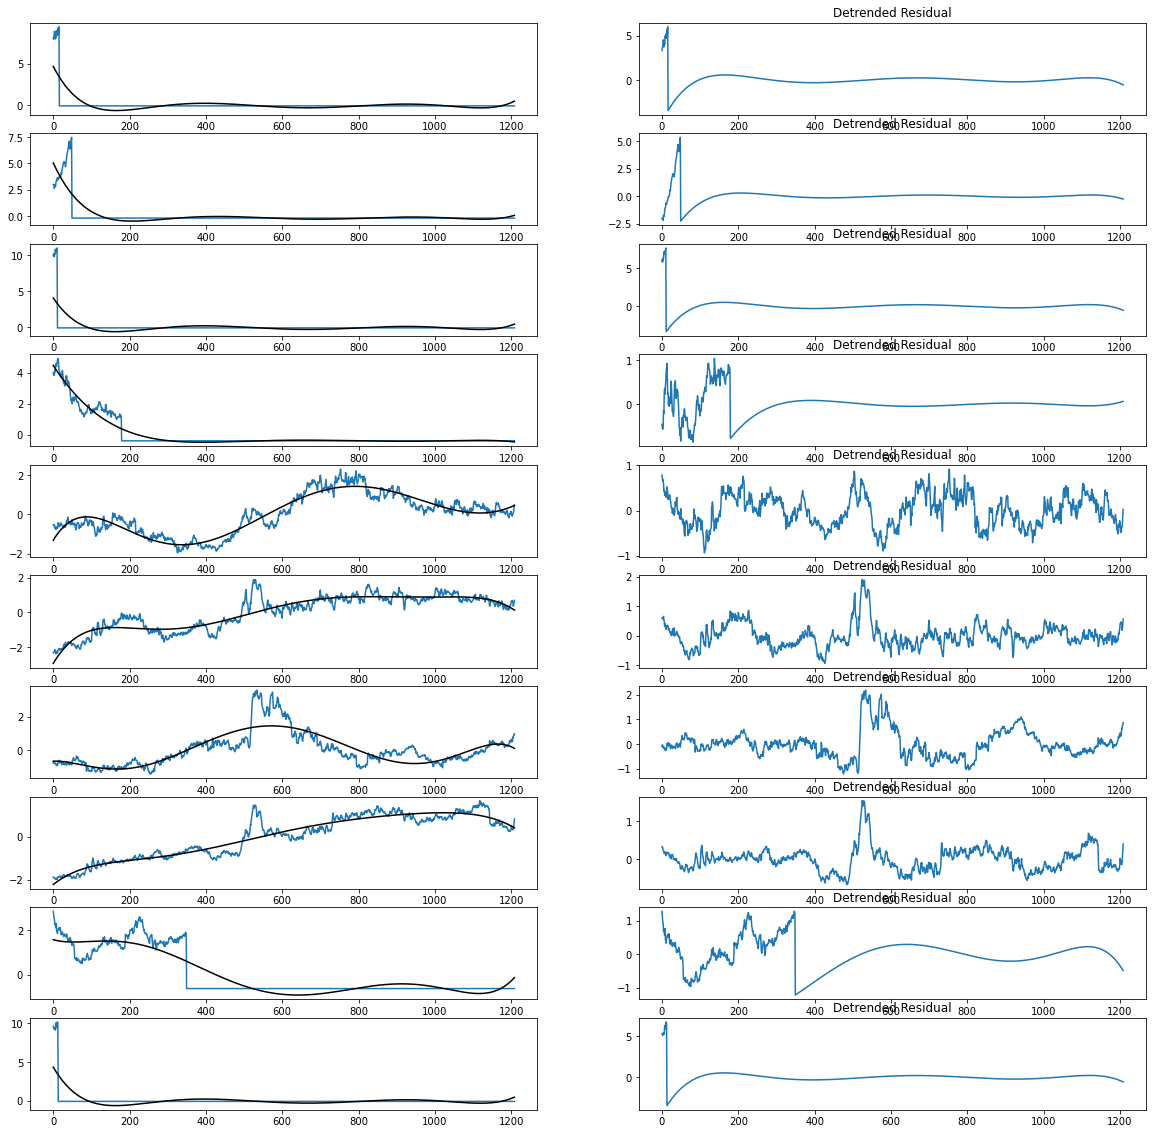

In [34]:
for i in range(data.shape[0]):
    y = data[i,:]
    model = np.polyfit(x, y, 6)
    predicted[i,:] = np.polyval(model, x)

fig, axis = plt.subplots(10, 2, figsize=(20,20))
for i, ax in enumerate(axis):
    axis[i,0].plot(x, data[i,:])
    axis[i,0].plot(x, predicted[i,:], 'k-')
    
    axis[i,1].plot(x, data[i,:] - predicted[i,:])
    axis[i,1].set(title='Detrended Residual')

In [35]:
data_de = data - predicted

In [36]:
n=20
data_smooth = np.zeros((data_de.shape[0], data_de.shape[1]-(n-1)))
for i in range(data_de.shape[0]):
    data_smooth[i,:] = np.convolve(data_de[i,:], np.ones(n)/n, mode='valid')

In [37]:
hann_s = np.hanning(data_smooth.shape[1])

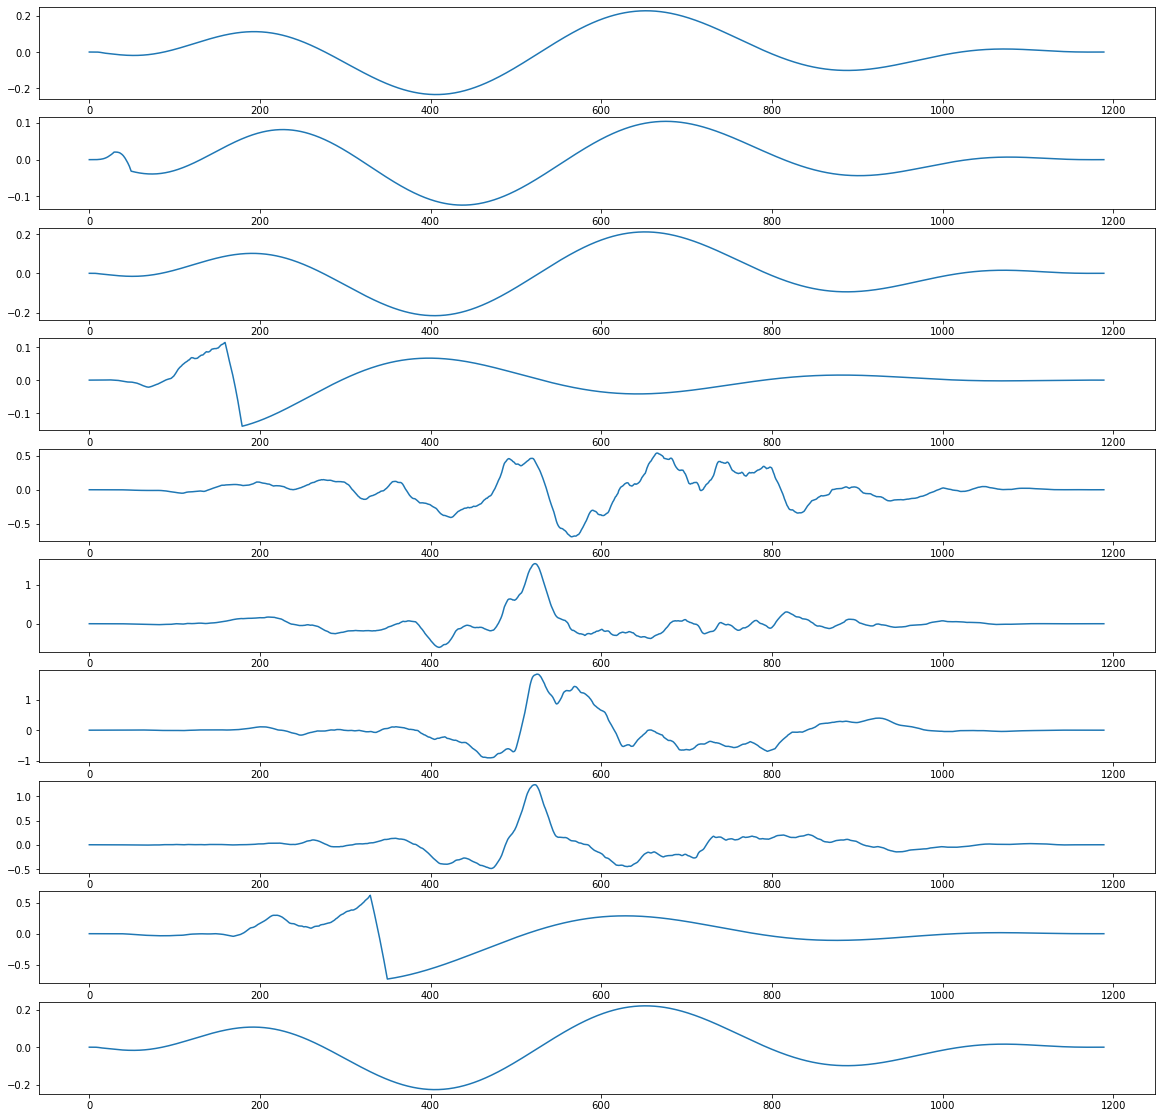

In [38]:
x = np.linspace(0, data_smooth[0,:].shape[0], data_smooth[0,:].shape[0])
signal_hann = np.zeros(data_smooth.shape)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    signal_hann[i,:] = data_smooth[i,:]*hann_s
    ax.plot(x, signal_hann[i,:]);

<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-39-e62683810e18>:4: ComplexWarning: Casting complex val

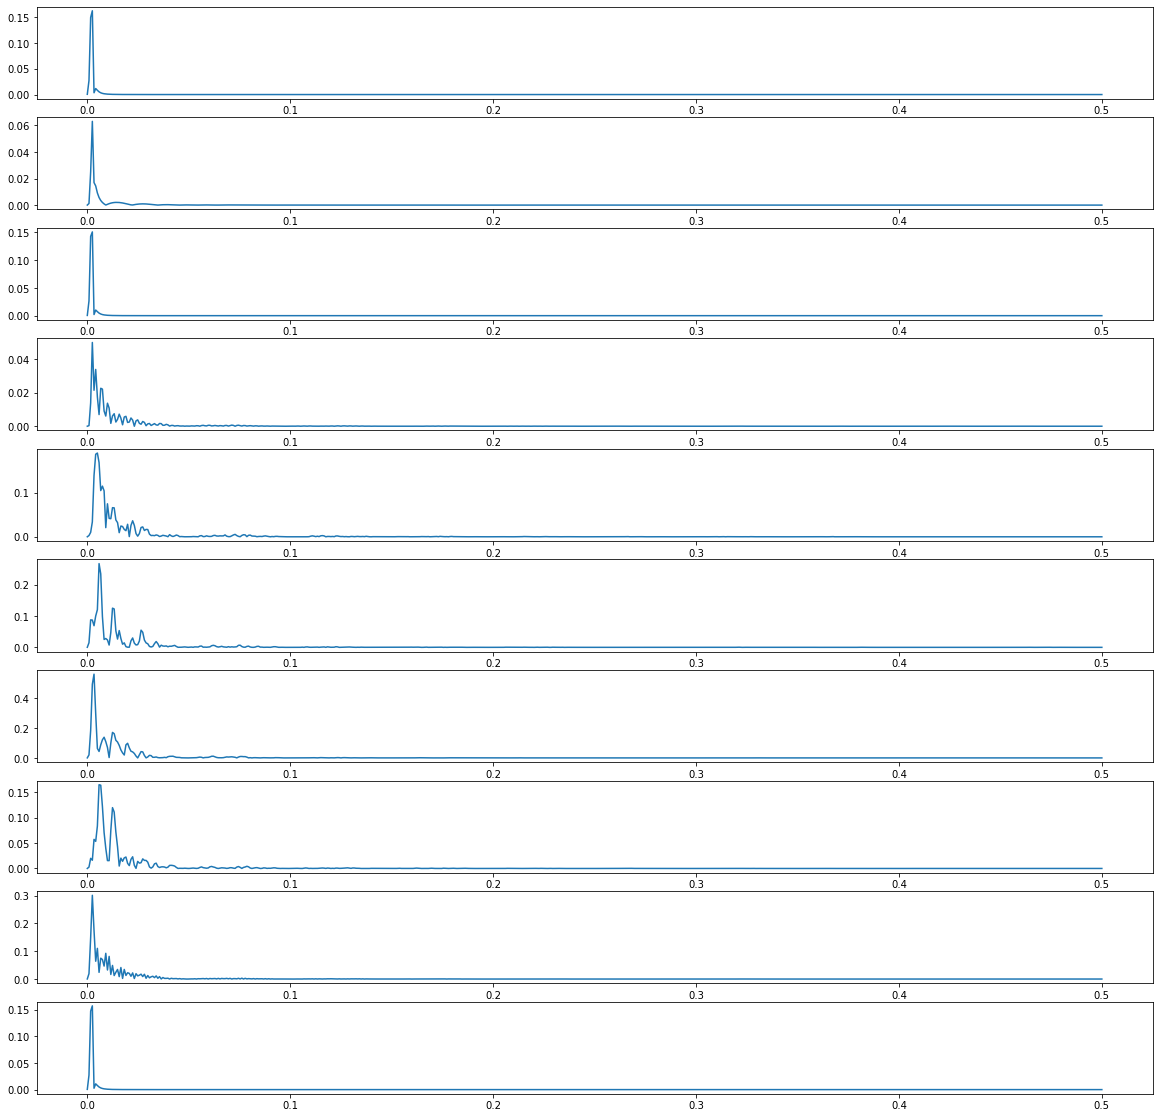

In [39]:
y_hann = np.zeros(signal_hann.shape)
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    y_hann[i,:] = np.fft.fft(signal_hann[i,:])
    ax.plot(X, 2.0*np.abs(y_hann[i,:N])/N);

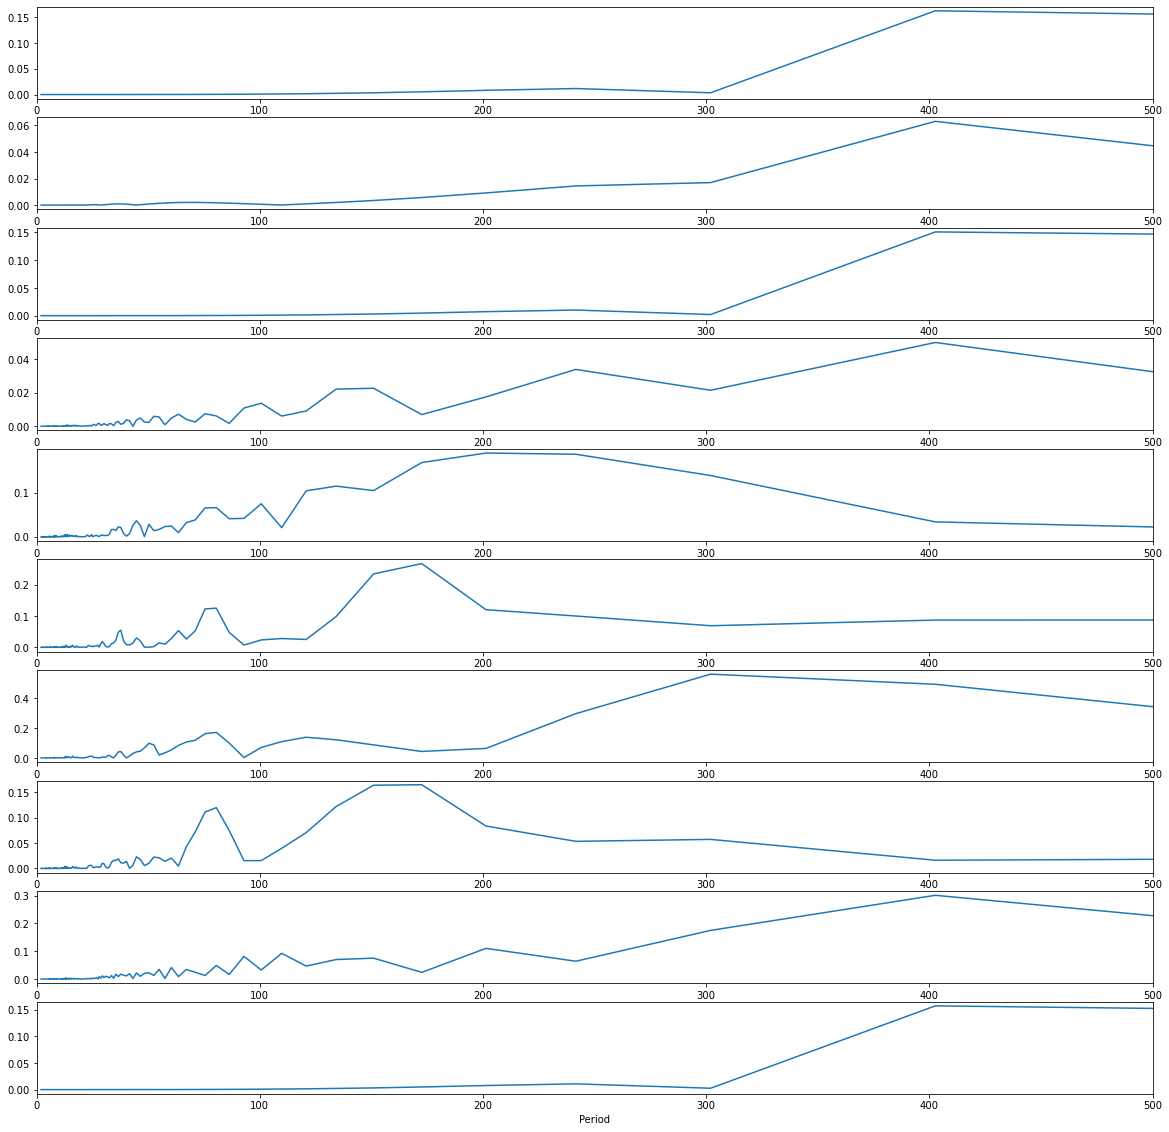

In [40]:
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    ax.plot(Xp, 2.0*np.abs(y_hann[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')
    ax.set_xlim(0,500)

# Changepoint Detection

* https://techrando.com/2019/08/14/a-brief-introduction-to-change-point-detection-using-python/
* https://centre-borelli.github.io/ruptures-docs/user-guide/detection/pelt/

In [41]:
!pip install ruptures

In [42]:
import ruptures as rpt

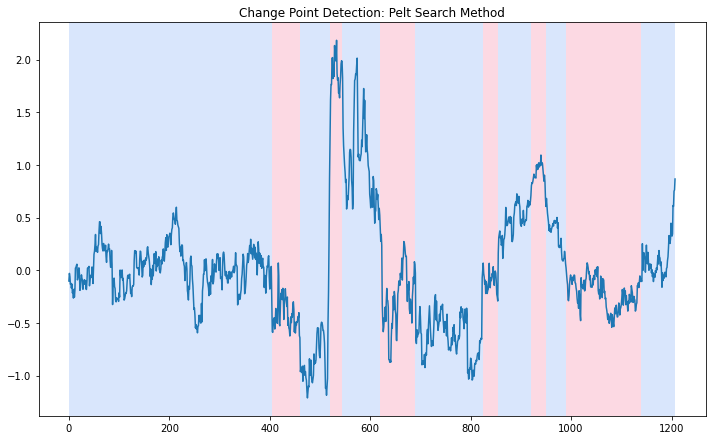

In [43]:
#RUPTURES PACKAGE
#Changepoint detection with the Pelt search method
model="rbf"
algo = rpt.Pelt(model=model).fit(data_de[6,:])
result = algo.predict(pen=10)
rpt.display(data_de[6,:], result, figsize=(10, 6))
plt.title('Change Point Detection: Pelt Search Method')
plt.show()  

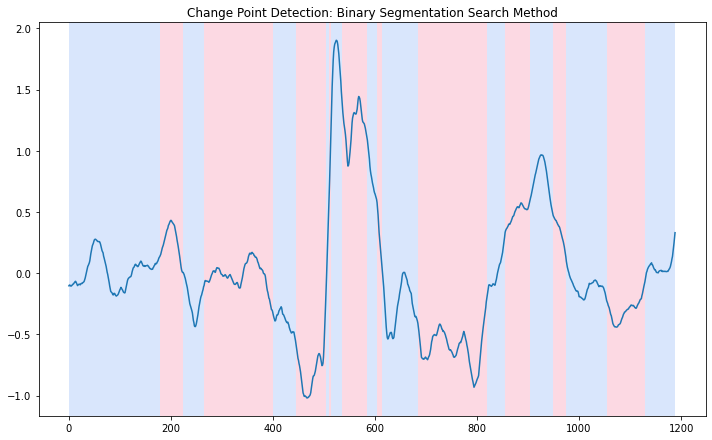

In [44]:
#Changepoint detection with the Binary Segmentation search method
model = "l2"  
algo = rpt.Binseg(model=model).fit(data_smooth[6,:])
my_bkps = algo.predict(n_bkps=20)
# show results
rpt.show.display(data_smooth[6,:], my_bkps, figsize=(10, 6))
plt.title('Change Point Detection: Binary Segmentation Search Method')
plt.show()

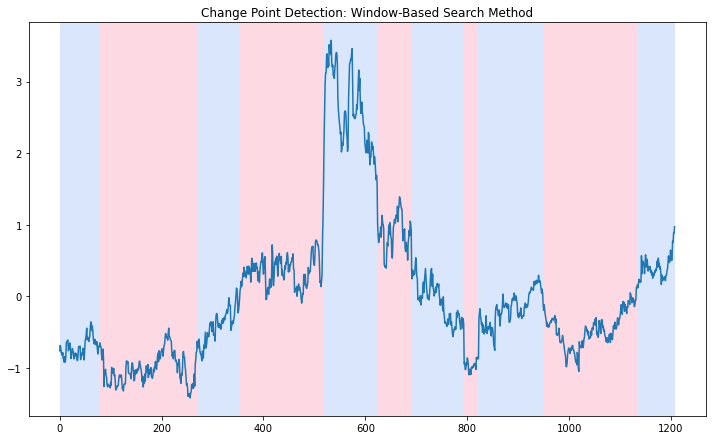

In [45]:
#Changepoint detection with window-based search method
model = "l2"  
algo = rpt.Window(width=40, model=model).fit(data[6,:])
my_bkps = algo.predict(n_bkps=10)
rpt.show.display(data[6,:], my_bkps, figsize=(10, 6))
plt.title('Change Point Detection: Window-Based Search Method')
plt.show()

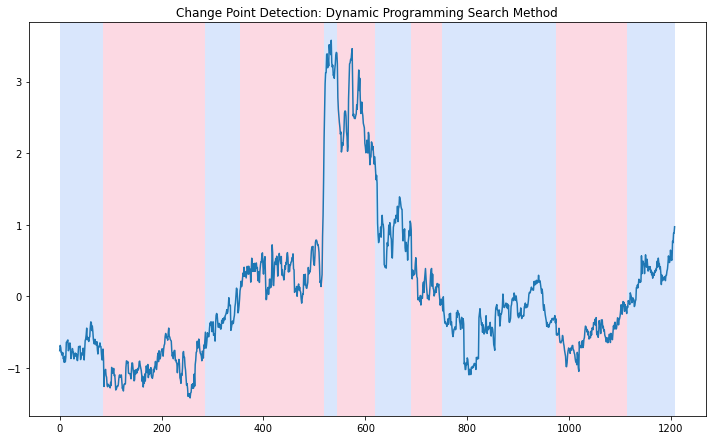

In [46]:
#Changepoint detection with dynamic programming search method
model = "l1"  
algo = rpt.Dynp(model=model, min_size=3, jump=5).fit(data[6,:])
my_bkps = algo.predict(n_bkps=10)
rpt.show.display(data[6,:], my_bkps, figsize=(10, 6))
plt.title('Change Point Detection: Dynamic Programming Search Method')
plt.show()

# Local extrems

In [47]:
from scipy.signal import argrelextrema
import pandas as pd

In [48]:
ilocs_min = argrelextrema(data_smooth[6,:], np.less_equal, order=10)[0]
ilocs_max = argrelextrema(data_smooth[6,:], np.greater_equal, order=10)[0]

In [49]:
ilocs_min

array([   4,   17,   93,  109,  162,  247,  334,  404,  468,  496,  547,
        625,  703,  755,  794,  897, 1009, 1073, 1111, 1155, 1171])

In [50]:
ilocs_max

array([  13,   52,  102,  141,  200,  290,  316,  359,  416,  524,  568,
        656,  727,  774,  886,  926, 1032, 1102, 1142, 1161, 1188])

In [51]:
df = pd.DataFrame(data_smooth[6,:])
df.head()

,0
0,-0.103457
1,-0.097179
2,-0.097400
3,-0.104003
4,-0.105566


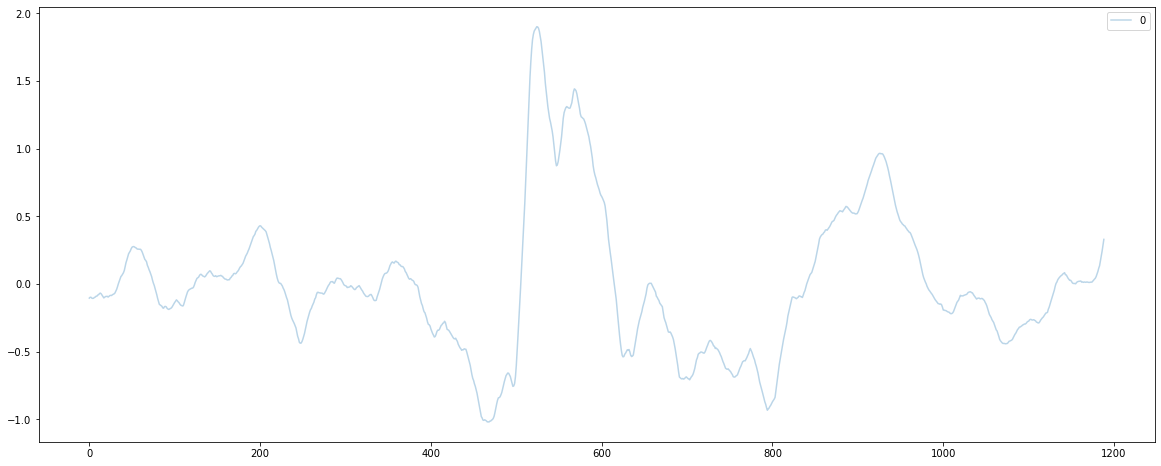

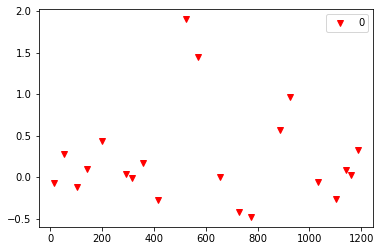

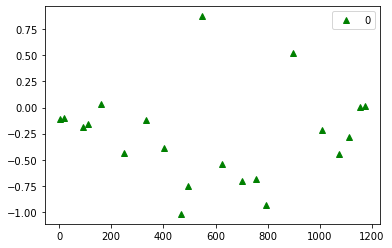

In [52]:
df.plot(figsize=(20,8), alpha=.3)
# filter prices that are peaks and plot them differently to be visable on the plot
df.iloc[ilocs_max].plot(style='.', lw=10, color='red', marker="v")
df.iloc[ilocs_min].plot(style='.', lw=10, color='green', marker="^")